# Exploring Datasets for thesis


In [63]:
import pandas as pd
import re
import pycountry
import matplotlib.pyplot as plt

### UN Food and Agriculture Fisheries Tuna Catch Dataset (1918-2023)

Data from UN FAO (https://zenodo.org/records/17494424)
Metadata/explanation here: https://www.fao.org/fishery/geonetwork/srv/eng/catalog.search#/metadata/global_nominal_catch_firms_level0

Need:

- codes for:
  - Fishing Fleet
    - uses ISO 3166 country codes
  - Species
    - BET Bigeye Tuna
    - YFT Yellowfin Tuna
    - BFT Atlantic Bluefin Tuna
    - PBF Pacific Bluefin Tuna
    - SBF Southern Bluefin Tuna
  - Measurement Type
    - NC Nominal Catch
    - NL Nominal Landings
    - DL or DD is Discarded Alive or Dead
  - unit
    - t (metric tons)


In [64]:
fao_all = pd.read_csv("datasets/global_nominal_catch_firms_level0_harmonized.csv")

#get year from the first four numbers in time_start
fao_all["year"] = fao_all["time_start"].str.extract(r"(\d{4})").astype(int)
fao_all.head()

,source_authority,fishing_fleet,time_start,time_end,geographic_identifier,gear_type,species,fishing_mode,measurement,measurement_type,measurement_unit,measurement_processing_level,measurement_value,year
0,CCSBT,AUS,1965-01-01,1965-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,4675.024565,1965
1,CCSBT,AUS,1965-01-01,1965-12-31,WCPFC,99.9,SBF,UNK,catch,NC,t,raised,2200.975435,1965
2,CCSBT,AUS,1966-01-01,1966-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,5881.819586,1966
3,CCSBT,AUS,1966-01-01,1966-12-31,WCPFC,99.9,SBF,UNK,catch,NC,t,raised,2126.180415,1966
4,CCSBT,AUS,1967-01-01,1967-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,3527.866462,1967


In [69]:
#atlantic bluefin tuna subset
atlantic_bluefin_tuna = fao_all[fao_all["species"].str.contains("BFT", case=False, na=False)]
atlantic_bluefin_tuna.head() #4000 rows

#column for year: take first four numbers in time_start column
atlantic_bluefin_tuna["year"] = atlantic_bluefin_tuna["time_start"].str.extract(r"(\d{4})").astype(int)
atlantic_bluefin_tuna.head()

#group by year, and for each source_authority, sum the catch
catch_by_year = atlantic_bluefin_tuna.groupby(["year", "source_authority"])["measurement_value"].sum().reset_index()
catch_by_year.head()


/var/folders/s6/l4_0rpsd3xs3vxs6x047x7t80000gn/T/ipykernel_13613/1153987540.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atlantic_bluefin_tuna["year"] = atlantic_bluefin_tuna["time_start"].str.extract(r"(\d{4})").astype(int)


,year,source_authority,measurement_value
0,1950,ICCAT,27829.3579
1,1951,ICCAT,31333.8651
2,1952,ICCAT,39700.7939
3,1953,ICCAT,40359.0521
4,1954,ICCAT,37979.9940


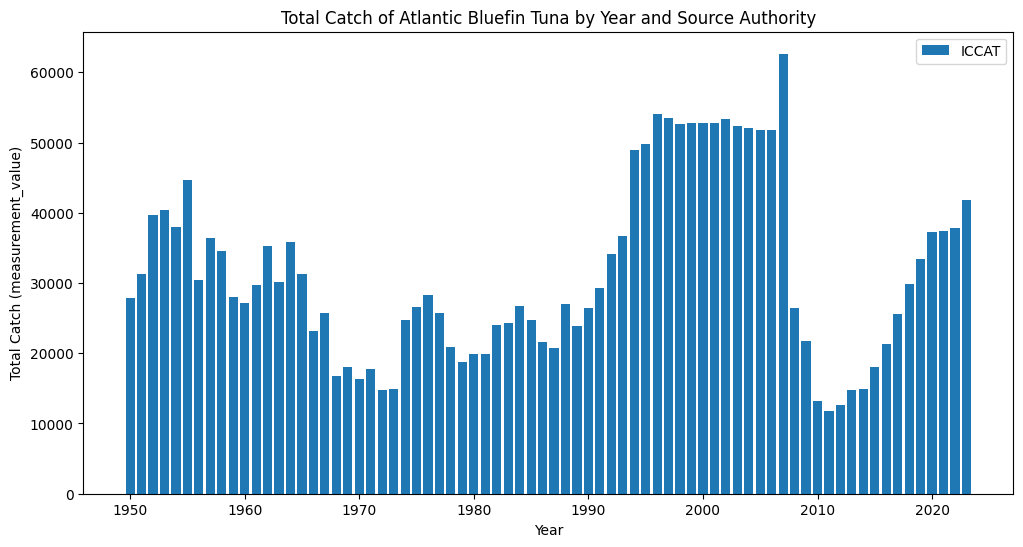

In [66]:
#bar plot of measurement_value by year, with different colors for each source_authority
plt.figure(figsize=(12, 6))
for authority in catch_by_year["source_authority"].unique():
    authority_data = catch_by_year[catch_by_year["source_authority"] == authority]
    plt.bar(authority_data["year"], authority_data["measurement_value"], label=authority)
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Atlantic Bluefin Tuna by Year and Source Authority")
plt.legend()
plt.show()


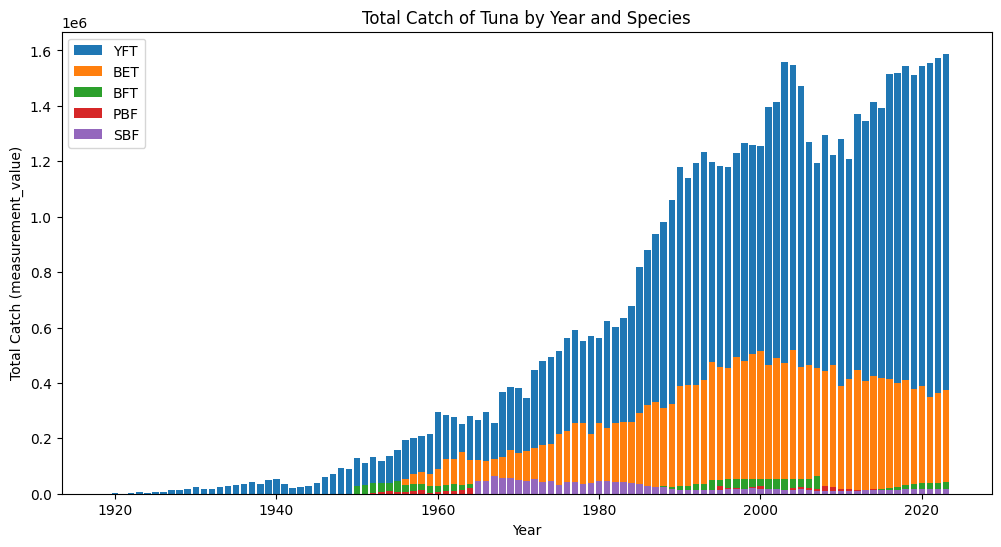

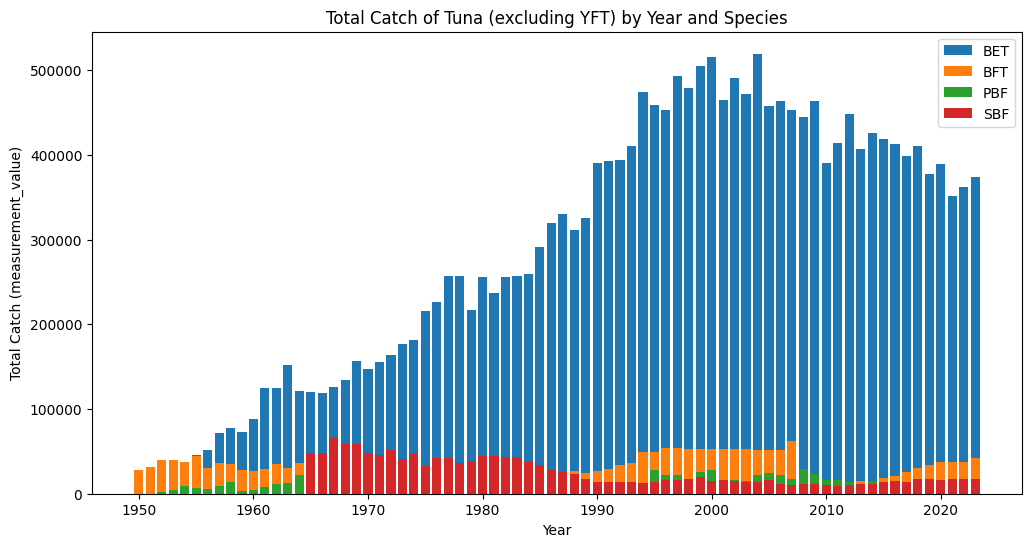

In [75]:
#subset for all tuna: BFT, YFT, PBF, SBF, BET
all_tuna = fao_all[fao_all["species"].str.contains("BFT|PBF|SBF|YFT|BET", case=False, na=False)]





#bar plot of measurement_value by year, with different colors for each species
catch_by_year_tuna = all_tuna.groupby(["year", "species"])["measurement_value"].sum().reset_index()
plt.figure(figsize=(12, 6))
for species in catch_by_year_tuna["species"].unique():
    species_data = catch_by_year_tuna[catch_by_year_tuna["species"] == species].groupby("year")["measurement_value"].sum().reset_index()
    plt.bar(species_data["year"], species_data["measurement_value"], label=species)
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Tuna by Year and Species")
plt.legend()

#same plot but exclude YFT
catch_by_year_tuna_no_yft = all_tuna[~all_tuna["species"].str.contains("YFT", case=False, na=False)].groupby(["year", "species"])["measurement_value"].sum().reset_index()
plt.figure(figsize=(12, 6))
for species in catch_by_year_tuna_no_yft["species"].unique():
    species_data = catch_by_year_tuna_no_yft[catch_by_year_tuna_no_yft["species"] == species].groupby("year")["measurement_value"].sum().reset_index()
    plt.bar(species_data["year"], species_data["measurement_value"], label=species)
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Tuna (excluding YFT) by Year and Species")
plt.legend()
plt.show()

,source_authority,fishing_fleet,time_start,time_end,geographic_identifier,gear_type,species,fishing_mode,measurement,measurement_type,measurement_unit,measurement_processing_level,measurement_value,year
0,CCSBT,AUS,1965-01-01,1965-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,4675.024565,1965
1,CCSBT,AUS,1965-01-01,1965-12-31,WCPFC,99.9,SBF,UNK,catch,NC,t,raised,2200.975435,1965
2,CCSBT,AUS,1966-01-01,1966-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,5881.819586,1966
3,CCSBT,AUS,1966-01-01,1966-12-31,WCPFC,99.9,SBF,UNK,catch,NC,t,raised,2126.180415,1966
4,CCSBT,AUS,1967-01-01,1967-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,3527.866462,1967


In [ ]:
#names? 

unrecognized = fao_all[fao_all["fishing_fleet"].notna()]["fishing_fleet"].apply(
    lambda x: x if pycountry.countries.get(alpha_3=x) is None else None
).dropna().unique()
print(unrecognized)

In [ ]:
fao_all["country_name"] = fao_all["fishing_fleet"].apply(
    lambda x: country.name if pd.notnull(x) and (country := pycountry.countries.get(alpha_3=x)) else None
)

fao_all.head()